### CIFAR-10

- 60,000 images
- size = 32×32
- 3 channels (RGB)
- 10 classes
- real objects

Classes include
- airplane
- automobile
- bird
- cat
- deer
- dog
- frog
- horse
- ship
- truck

<img src="images/cifar10_dataset_example.png">

### Compared to MNIST

- digits → objects
- grayscale → RGB
- blank background → clutter
- one stroke → textures + edges

Consequences

- linear models fail badly
- shallow CNNs struggle
- padding, depth, channels now matter
- robustness differences become clear

This is where CNNs justify their existence.

### Step-1: Load CIFAR-10

In [2]:
from torchvision import datasets, transforms

In [4]:
transform = transforms.ToTensor()

- converts image to tensor
- rescales pixel values from 0–255 → 0–1
- does not normalize yet

##### Load training data

In [5]:
train_data = datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=transform
)

100%|██████████| 170M/170M [01:20<00:00, 2.12MB/s] 


Extracting data\cifar-10-python.tar.gz to data


##### Load Testing Data

In [6]:
test_data = datasets.CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=transform
)

Files already downloaded and verified


### Step-2: Wrap with DataLoader

In [7]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

### Step-3: Inspect one batch

In [8]:
images, labels = next(iter(train_loader))
print(images.shape, labels.shape)

torch.Size([64, 3, 32, 32]) torch.Size([64])


Interpretation
- 64 images
- 3 color channels
- 32×32 pixels
- 64 labels

This confirms
- data loaded correctly
- shape is what CNN expects

#### What the 3 channels mean

Each image has
- channel 0 → Red
- channel 1 → Green
- channel 2 → Blue

So, the 3 channels together make up a colored RGB photo

### Step-4: Visualize a CIFAR-10 Image

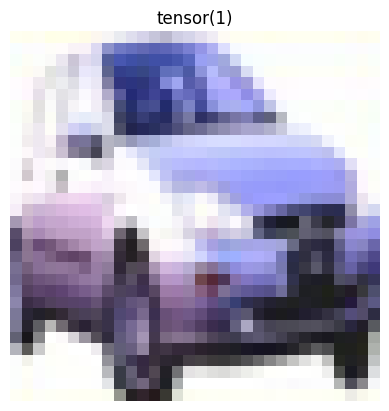

In [15]:
import matplotlib.pyplot as plt

img = images[0].permute(1, 2, 0)    # CHW → HWC
label = labels[0]

plt.imshow(img)
plt.title(label)
plt.axis("off")
plt.show()

Why permute(1, 2, 0)
- PyTorch uses [C, H, W]
- matplotlib expects [H, W, C]

This is a display-only operation.

- C - Channel
- H - Height
- W - Width


### Step-5: Building the model

#### First required change: input channels

MNIST

`[1, 28, 28]`


CIFAR-10

`[3, 32, 32]`


So this line must change:

`nn.Conv2d(1, 8, ...)`


to

`nn.Conv2d(3, 16, ...)`

Explanation

- `3` → RGB channels
- `16` → more filters because color adds complexity

#### Why we increase channel counts

In MNIST we used
- 8 → 16 channels

For CIFAR-10 we need more.

Reason

- textures
- color gradients
- object boundaries
- background clutter

So we start with:

- 16 channels
- then 32 channels

This lets the network
- represent richer features
- avoid collapsing information early

#### Padding is now mandatory

Without padding

- spatial size shrinks too fast
- edge information is lost
- object boundaries disappear

So every convolution uses padding.

Rule we adopt

- kernel size = 3
- padding = 1
- spatial size preserved

This keeps reasoning simple and stable.

#### Pooling strategy

Pooling

- reduces spatial resolution
- increases receptive field
- adds translation tolerance

But

- pooling too early loses detail

So we use this pattern

- 2 conv layers
- then 1 pooling layer

This is a standard CNN block.

#### Coding

In [31]:
import torch.nn as nn

cnn_model = nn.Sequential(
    nn.Conv2d(3, 16, kernel_size=3, padding=1),
    nn.ReLU(),
    
    nn.Conv2d(16, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    
    nn.MaxPool2d(2),
    
    nn.Flatten(),   # 32 × 16 × 16 = 8192
    nn.Linear(32 * 16 * 16, 10)
)

### Step-6: Setting up GPU run

In [32]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
cnn_model = cnn_model.to(device)

### Step-7: Loss and Optimizer

In [33]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.001)

### Step-8: Training Loop

In [34]:
epochs = 10

for epoch in range(epochs):
    cnn_model.train()
    epoch_loss = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        preds = cnn_model(images)
        loss = loss_fn(preds, labels)
        
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        epoch_loss += loss.item()
        
    epoch_loss /= len(train_loader)
    print(f"Epoch: {epoch} | Avg Loss: {epoch_loss:.4f}")

Epoch: 0 | Loss: 1.4762
Epoch: 1 | Loss: 1.1427
Epoch: 2 | Loss: 1.0096
Epoch: 3 | Loss: 0.9137
Epoch: 4 | Loss: 0.8447
Epoch: 5 | Loss: 0.7932
Epoch: 6 | Loss: 0.7497
Epoch: 7 | Loss: 0.7064
Epoch: 8 | Loss: 0.6750
Epoch: 9 | Loss: 0.6378


### Step-9: Evaluate accuracy

In [36]:
cnn_model.eval()
total = 0
correct = 0

for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)
    
    preds = cnn_model(images)
    predicted = preds.argmax(dim=1)
    
    correct += (predicted == labels).sum().item()
    total += labels.size(0)
    
accuracy = correct / total
print(accuracy)

0.665
